Introduction

    In this project I will inspect a relationship between GDP per capita and life expectancy at birth. These two components play crucial role in the quality of human life, but how do they interact? Based on the two datasets linked below I will try to determine the nature of the relationship between GDP per capita and life expectancy at birth, as well as some explanatory limits. In this analysis I will mostly rely on correlation and linear regression and non-linear transformation.


Datasets used in the project:

GDP per capita - https://data.worldbank.org/indicator/NY.GDP.PCAP.CD

Life expectancy at birth - https://data.worldbank.org/indicator/SP.DYN.LE00.IN

0. Loading libraries and initial inspection of the data

In [1]:
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
raw_gdp = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv',skiprows=4)
raw_life_expectancy = pd.read_csv('API_SP.DYN.LE00.IN_DS2_en_csv_v2_121663.csv', skiprows=4)

In [3]:
raw_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [4]:
raw_life_expectancy.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,64.049000,64.215000,64.602000,64.944000,65.303000,65.615000,...,75.620000,75.880000,76.019000,75.406000,73.655000,76.226000,76.353000,76.500000,NaN,NaN
1,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,44.169658,44.468838,44.877890,45.160583,45.535695,45.770723,...,62.591275,63.330691,63.857261,63.766484,62.979999,64.487152,65.146228,65.349930,NaN,NaN
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,32.799000,33.291000,33.757000,34.201000,34.673000,35.124000,...,62.406000,62.443000,62.941000,61.454000,60.417000,65.617000,66.035000,66.289000,NaN,NaN
3,Africa Western and Central,AFW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.779636,38.058973,38.681792,38.936918,39.194580,39.479784,...,56.626622,57.037104,57.149956,57.364736,57.362736,57.987850,58.855740,59.049811,NaN,NaN
4,Angola,AGO,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.933000,36.902000,37.168000,37.419000,37.704000,37.968000,...,62.122000,62.622000,63.051000,63.116000,62.958000,64.246000,64.617000,64.805000,NaN,NaN


1. Cleaning and transforming the tables

The tables are in the wide format which is difficult to read, so I will transform them using .melt() into more manageable form.

In [5]:
gdp = raw_gdp.melt(id_vars = ['Country Name', 'Country Code','Indicator Name', 'Indicator Code'], var_name = 'year', value_name ='gdp_per_capita')
gdp = gdp.drop(columns=['Indicator Name', 'Indicator Code'])
gdp.head(20)

,Country Name,Country Code,year,gdp_per_capita
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,186.089204
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,121.936832
4,Angola,AGO,1960,NaN
5,Albania,ALB,1960,NaN
6,Andorra,AND,1960,NaN
7,Arab World,ARB,1960,NaN
8,United Arab Emirates,ARE,1960,NaN
9,Argentina,ARG,1960,778.251707


In [6]:
gdp['year'].unique()

array(['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967',
       '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975',
       '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024', '2025', 'Unnamed: 70'], dtype=object)

We can notice that the table contains not only some null values, but also there is 'Unnamed: 70' in the year column.

In [7]:
gdp = gdp[gdp['year']!='Unnamed: 70']

In [8]:
gdp.isnull().sum()

Country Name         0
Country Code         0
year                 0
gdp_per_capita    2995
dtype: int64

It is likely that the amount of nulls is time dependent - the lack of information should decrease along with post Cold war period and expanding globaliztaion. For now I will try to find the range of data containing fewest null values. This means using data containing information from as many countries as possible. I expect that this variety of information brings nuance into the analysis.

In order to do that I will group my data by year and filter out years containing more than 10 null values.

In [9]:
columns_containing_nulls= gdp[gdp['gdp_per_capita'].isnull()]
gdp_nulls = columns_containing_nulls.groupby(['year'])['year'].count()
gdp_nulls[gdp_nulls.values<10]

year
2002    9
2003    9
2004    9
2005    9
2006    8
2007    8
2008    7
2009    5
2010    5
2011    4
2012    6
2013    6
2014    5
2015    6
2016    7
2017    7
2018    7
2019    7
2020    8
2021    8
2022    9
Name: year, dtype: int64

Tableau chart showing the relationship between time and amount of lacking data: https://public.tableau.com/views/MissingGDPdata/Sheet1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

We can now see that the most data rich period is 2002–2022. That's 20 years, which should be sufficient. From now on I will use data from this time frame.

In [10]:
gdp_less_nulls=gdp_nulls[gdp_nulls<10].index
gdp_less_nulls

Index(['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022'],
      dtype='object', name='year')

In [11]:
new_gdp = gdp[gdp['year'].isin(gdp_less_nulls)]
new_gdp.head()

,Country Name,Country Code,year,gdp_per_capita
11172,Aruba,ABW,2002,21307.248251
11173,Africa Eastern and Southern,AFE,2002,630.512328
11174,Afghanistan,AFG,2002,178.954088
11175,Africa Western and Central,AFW,2002,619.337335
11176,Angola,AGO,2002,999.065856


In [12]:
new_gdp = new_gdp.dropna()

Let's also transform the Life expectancy table.

In [13]:
life = raw_life_expectancy.melt(id_vars = ['Country Name', 'Country Code','Indicator Name', 'Indicator Code'], var_name = 'year', value_name ='life_expectancy')
life = life.drop(columns=['Indicator Name', 'Indicator Code'])
life.head(20)

,Country Name,Country Code,year,life_expectancy
0,Aruba,ABW,1960,64.049000
1,Africa Eastern and Southern,AFE,1960,44.169658
2,Afghanistan,AFG,1960,32.799000
3,Africa Western and Central,AFW,1960,37.779636
4,Angola,AGO,1960,37.933000
5,Albania,ALB,1960,56.413000
6,Andorra,AND,1960,72.094000
7,Arab World,ARB,1960,44.794056
8,United Arab Emirates,ARE,1960,50.651000
9,Argentina,ARG,1960,64.242000


In [14]:
life_exp_nulls= life[life['life_expectancy'].isnull()]
life_null_count = life_exp_nulls.groupby(['year'])['year'].count()
life_null_count.sort_values(ascending = False).head(10)

year
Unnamed: 70    266
2025           266
1960             3
1965             3
1964             3
1963             3
1961             2
1962             2
1968             2
1967             2
Name: year, dtype: int64

In [15]:
life = life.dropna()

In [16]:
life = life[life['year']!= 'Unnamed: 70']
life['year'].unique()

array(['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967',
       '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975',
       '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'], dtype=object)

In [17]:
life['year'].dtype, new_gdp['year'].dtype

(dtype('O'), dtype('O'))

The 'year' columns contain objects instead of integers, so I will have to convert them into appropriate format.

In [18]:
new_gdp['year'] = new_gdp['year'].astype(int)
life['year'] = life['year'].astype(int)
life['year'].dtype, new_gdp['year'].dtype

(dtype('int64'), dtype('int64'))

Now we can just merge our two tables. Using inner merge will result in the table containing only those positions that found their match in the other one, so the data will be only from the previously restricted time range.

In [19]:
gdp_life = new_gdp.merge(life, on=['year', 'Country Code'], how='inner')
gdp_life = gdp_life.drop(columns=['Country Name_y'])
gdp_life.rename(columns={'Country Name_x':'Country Name'}, inplace=True)
gdp_life.head()

,Country Name,Country Code,year,gdp_per_capita,life_expectancy
0,Aruba,ABW,2002,21307.248251,73.135000
1,Africa Eastern and Southern,AFE,2002,630.512328,53.206744
2,Afghanistan,AFG,2002,178.954088,56.225000
3,Africa Western and Central,AFW,2002,619.337335,51.108247
4,Angola,AGO,2002,999.065856,47.874000


2. Exploration

First, I'll check which countries have the highest life expectancy and the highest GDP per capita.

In [20]:
mean_life_exp = gdp_life.groupby('Country Name')['life_expectancy'].mean()
mean_life_exp.nlargest(10)

Country Name
Monaco                  84.863429
Andorra                 83.582429
San Marino              83.482476
Hong Kong SAR, China    83.406341
Japan                   83.175319
Macao SAR, China        82.548432
Switzerland             82.486411
Liechtenstein           82.136237
Iceland                 82.082927
Italy                   82.046574
Name: life_expectancy, dtype: float64

In [21]:
mean_life_exp = gdp_life.groupby('Country Name')['gdp_per_capita'].mean()
mean_life_exp.nlargest(10)

Country Name
Monaco            169939.586886
Liechtenstein     147078.484356
Luxembourg        105630.100695
Bermuda           100108.757682
Cayman Islands     82020.925849
Norway             80977.197073
Switzerland        75848.783648
Qatar              69294.643057
Isle of Man        69279.832105
Ireland            62894.993304
Name: gdp_per_capita, dtype: float64

Having both life expectancy and GDP per capita in one table allows to make a simple chart mapping the relationship between them.

Chart in Tableau: https://public.tableau.com/app/profile/bartek.owsiany/viz/GDPpercapitaandlifeexpectancy/Sheet1#1

Scatter plot in Tableau allows to examine every data point on chart showing the country name, average life expectancy and average GDP per capita.

,life_expectancy,gdp_per_capita,year
life_expectancy,1.000000,0.594584,0.180302
gdp_per_capita,0.594584,1.000000,0.110111
year,0.180302,0.110111,1.000000


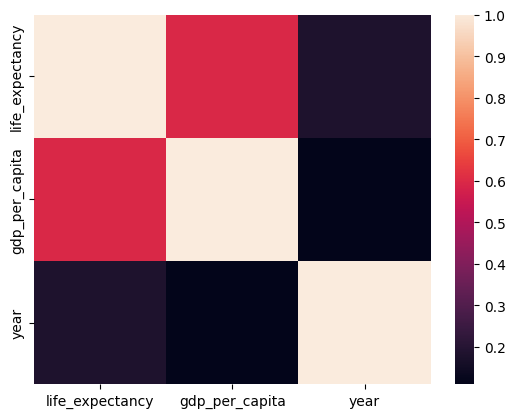

In [22]:
cor = gdp_life[['life_expectancy', 'gdp_per_capita', 'year']].corr()
sns.heatmap(cor)
cor

So far this gives us moderate correlation of 0.59 between GDP per capita and Life expectancy. Now let's try simple linear regression to further explore the relationship between those variables. 

It is also worth noting that there is basically no correlation between year and other two factors in our restricted time range. This would suggest that time does not play a big role in an increase of gdp per capita or life expectancy. This is false, since we know that especially global life expectancy is on a constant rise (https://ourworldindata.org/grapher/life-expectancy). It is most likely not due to a falsity of the data, but the restricted time span.

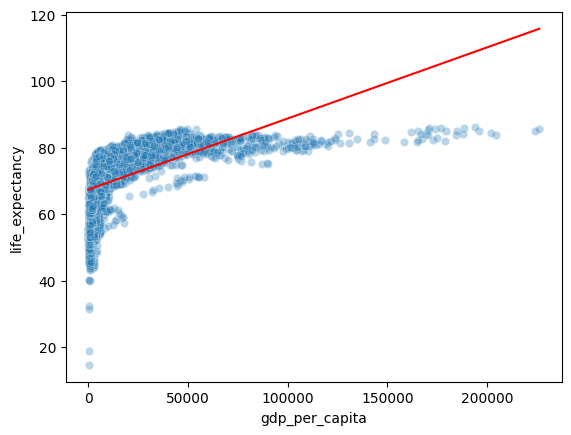

In [23]:
x = gdp_life['gdp_per_capita']
y = gdp_life['life_expectancy']


slope, intercept, r, p, se = scipy.stats.linregress(x, y)
x_sorted = sorted(x)

def regr(x):
    return intercept + slope*x

m = list(map(regr, x_sorted))

sns.scatterplot(data=gdp_life, x=x, y=y, alpha=0.3)
plt.plot(x_sorted, m, color='r')
plt.show()

Let's now check p-value and value of r-squared value to see statistical significance and how much of GDP per capita accounts for life expectancy.

In [24]:
p, r**2

(np.float64(0.0), np.float64(0.35353014889375356))

The outcome is less than desirable and as we can see, the data does not seem to have a clear linear relationship as expected. The p-value is 0 which means high statistical significance, but the r-squared (0.35) is low. In the lowest part of gdp per capita small amount of increase does result in a significant increase of life expectancy, but only to a certain point. After a certain value the chart shows a diminishing returns. The shape of this chart resembles more of a logarithmic scale than the linear one.

Text(0.5, 1.0, 'Logarithmic Function')

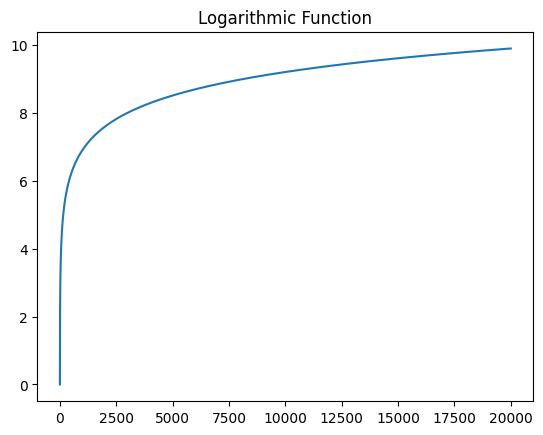

In [25]:
x=range(1, 20000)
y=np.log(x)


sns.lineplot(x=x, y=y)
plt.title('Logarithmic Function')

 This might be because for a person living in a 1500 dollars per capita country, additional 500 makes big difference, but for people in a country with higher gdp per capita, let's say 50 000, additional 500 makes less of a difference. That's why we have nonlinear relation. This very relationship is actually called Preston curve (https://en.wikipedia.org/wiki/Preston_curve). In this situation we can use a nonlinear transformation on the x values to yield better results from the linear regression.

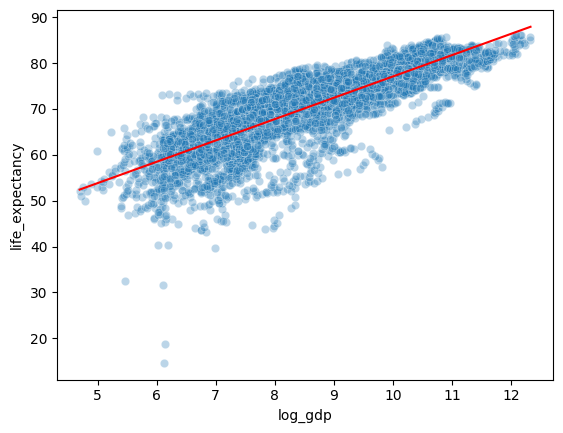

In [26]:
gdp_life['log_gdp'] = np.log(gdp_life['gdp_per_capita'])

x = gdp_life['log_gdp']
y = gdp_life['life_expectancy']

slope, intercept, r, p, se = scipy.stats.linregress(x, y)


x_sorted = sorted(x)

def regr(x):
    return intercept + slope*x

m = list(map(regr, x_sorted))

sns.scatterplot(data= gdp_life, x=x, y=y, alpha=0.3)
plt.plot(x_sorted, m, color='r')
plt.show()

In [27]:
p, r**2

(np.float64(0.0), np.float64(0.6891216966587576))

This gives us much better results. The r-squared value almost doubled, from 0.35 to 0.68.

Until now, I've only used data from a limited time frame (2002–2022), where the data had the greatest diversity and reliability. Now we can also test the result using the entire time frame.

In [28]:
gdp['year'] = gdp['year'].astype(int)

longer = gdp.merge(life, on=['year', 'Country Code', 'Country Name'], how='inner')
longer = longer.dropna()

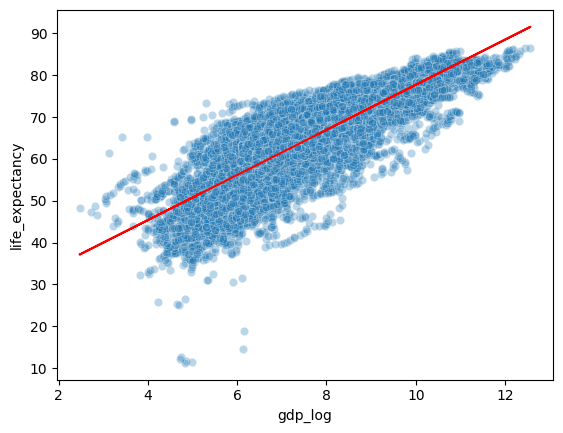

In [29]:
longer['gdp_log'] = np.log(longer['gdp_per_capita'])

x= longer['gdp_log']
y= longer['life_expectancy']


slope, intercept, r, p, se = scipy.stats.linregress(x, y)


def regr(x):
    return intercept + slope*x

m = list(map(regr, x))

sns.scatterplot(data=longer, x=x, y=y, alpha=0.3)
plt.plot(x, m, color='r')
plt.show()

In [30]:
r**2

np.float64(0.7304854239050722)

The result actually improved from 0.68 to 0.73. Larger time frame further confirms the logarithmic nature of the relationship between life expectancy and GDP per capita.

3. Limitations and interpretations

Including the data from the wider time range gives us better results, but we have to keep in mind that the large amount of missing values from many countries may expose the results to a bias coming from the few countries with similar culture, political and economic conditions that appeared early in the data collection period. It might be that the logarithmic relationship is stronger in some countries because the factors not included in the analysis play smaller role. For example: the logarithmic relationship holds true provided that the growth in GDP per capita is reflected in growth of public services, like healthcare, education and overall better living conditions, rather than just growing wealth inequality. Besides that, there are always factors that are more unforeseeable, like war or pandemic that might have significant impact on the model.

Here we have to consider why GDP per capita does not explain the life expectancy in its entirety. GDP per capita does not show possible income inequality as well as social inequality in general, so higher GDP per capita might not mean improved standards of living, which in turn should be reflected in length of life expectancy. At the same time it is difficult to establish the exact structure of causation - does the GDP per capita influences the life expectancy or is it the other way around? Most likely these two factors both influence each other in some way - factors that are reflected in longevity (like good living conditions, physical and mental health etc.) might influence productivity, which in turn increases GDP per capita, but higher GDP per capita might contribute to the increase of life expectancy.

4. Conclusion

This analysis confirms that there is a strong logarithmic relationship between life expectancy and GDP per capita: R²=0.68 based on more restricted, but also more diverse data range (2002-2022) and R²=0.73 using the whole range of data (1960-2024). The outcome coincides with the Preston curve, which shows that, on average, people born in poorer countries are expected to live shorter than those that were born in the wealthier countries. At the same time the link between income and life expectancy follows diminishing returns - for countries with low GDP per capita relatively small increase brings large gains in life expectancy, but at a certain point, as the GDP per capita grows the increase of income brings smaller gains in life expectancy.
Our logarithmic model of the relationship between life expectancy and GDP per capita is valid and explains around 70% of the variation in life expectancy. At the same time there are still many other important factors and our model will hold true provided that there are certain base conditions maintained, like improvement of the overall living conditions along with growing GDP per capita, rather than wealth inequality or lack of wars.